## **GROVER'S ALGORITHM**

Algoritma Grover adalah algoritma kuantum untuk mencari satu solusi dari N kemungkinan tak teurut dengan kompleKsitas $ O(\sqrt{N}) $.

#### ***1. Import Library***

QuantumCircuit => untuk membangun circuit Grover

Statevector => melihat amplitudo tanpa perhitungan

AerSimulator => backend (tempat menjelankan) simulator modern

transpile => menyesuaikan circuit dengan backend

In [102]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np


#### ***2. Membuat Parameter Sistem***

In [103]:
n = 3           #number of qubits
target = "101"
N = 2**n        #number of possible states


#### ***3. Membuat Circuit & Superposisi Awal***

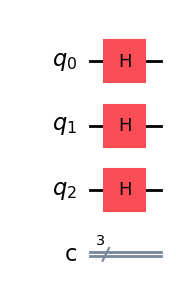

In [104]:
qc = QuantumCircuit(n,n)
qc.h(range(n))
qc.draw('mpl')

#### ***4. Membuat Oracle***

Oracle berfungsi untuk membalik fase target: $$ O∣x⟩=(−1)^{f(x)}∣x⟩ $$ 
Namun tidak merubah probabilitas, hanya merubah fase. Misal: 

$ ∣x⟩ = $ state basis (misalnya $ |000⟩ $, $ |101⟩ $, dll)

$ f(x) = $ fungsi yang mengecek apakah x target atau bukan (1 = kalau x adalah target, 0 = kalau bukan)

Sehingga, ketika $ f(x)=0 $ maka oracle akan berubah menjadi negatif


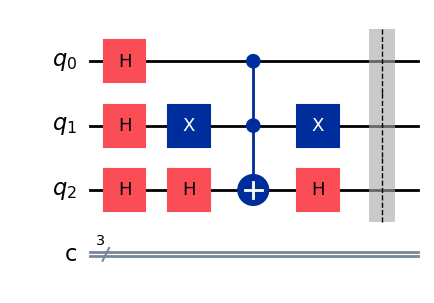

In [105]:
for i, bit in enumerate(target):   #iterasi setiap bit dalam target
    if bit == '0':
        qc.x(i)
    
qc.h(n-1)   #mengaplikasikan hadamard pada qubit target
qc.mcx([0,1], 2) #mengaplikasikan multi-controlled X gate dengan kontrol pada semua qubit kecuali yang terakhir
qc.h(n-1)   #mengaplikasikan hadamard lagi pada qubit target

for i, bit in enumerate(target):   #iterasi kembali untuk mengembalikan qubit yang diubah
    if bit == '0':
        qc.x(i)

qc.barrier()   #menambahkan barrier untuk memisahkan bagian oracle dan diffuser
qc.draw('mpl')

#### ***5. Diffusion Operator***

Diffusion operator berfungsi untuk merotasikan state awal sebanyak theta untuk mendekati target.

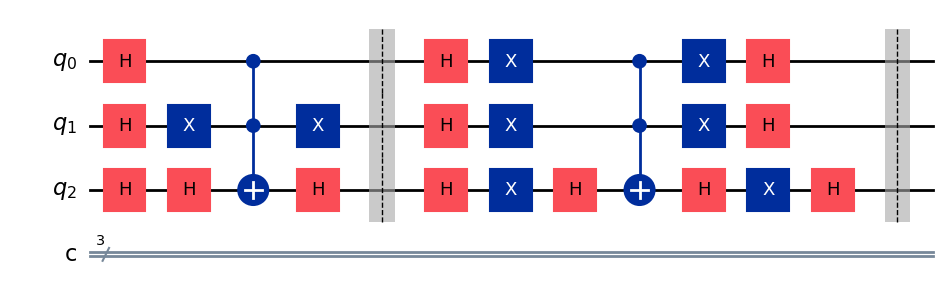

In [106]:
qc.h(range(n))   #mengaplikasikan hadamard pada semua qubit untuk mengubah ke basis amplitudo
qc.x(range(n))   #mengaplikasikan X gate pada semua qubit untuk mengubah ke basis amplitudo

qc.h(n-1)   #mengaplikasikan hadamard pada qubit target
qc.mcx([0,1], 2) #mengaplikasikan multi-controlled X
qc.h(n-1)   #mengaplikasikan hadamard lagi pada qubit target

qc.x(range(n))   #mengaplikasikan X gate lagi untuk mengembalikan ke basis semula
qc.h(range(n))   #mengaplikasikan hadamard lagi untuk mengembal

qc.barrier()   #menambahkan barrier untuk memisahkan bagian diffuser dan pengukuran
qc.draw('mpl')

#### ***Menambahkan Iterasi Kedua (Optional)***

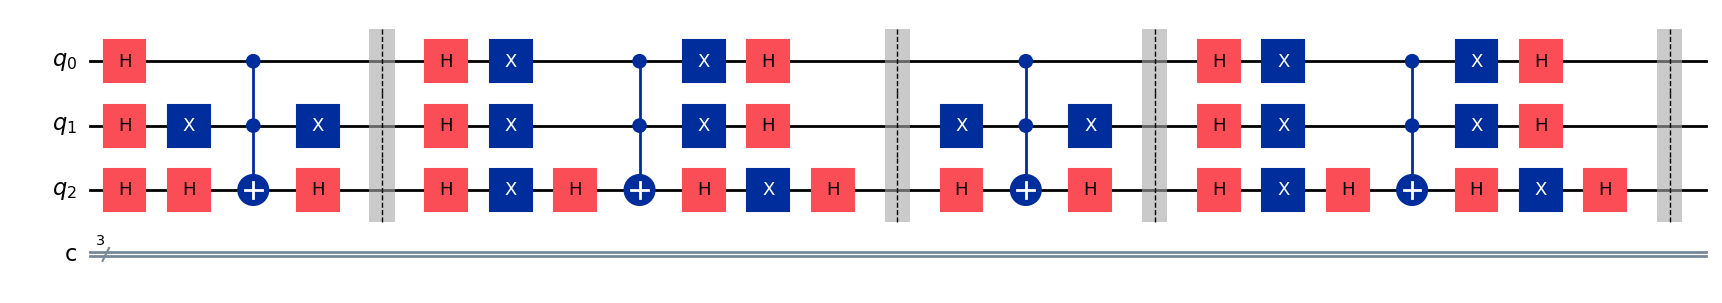

In [107]:
#mengulangi oracle
for i, bit in enumerate(target):   #iterasi setiap bit dalam target
    if bit == '0':
        qc.x(i)

qc.h(n-1)   #mengaplikasikan hadamard pada qubit target
qc.mcx([0,1], 2) #mengaplikasikan multi-controlled X gate dengan kontrol pada semua qubit kecuali yang terakhir
qc.h(n-1)   #mengaplikasikan hadamard lagi pada qubit target

for i, bit in enumerate(target):   #iterasi kembali untuk mengembalikan qubit yang diubah
    if bit == '0':
        qc.x(i)
qc.barrier()   #menambahkan barrier untuk memisahkan bagian oracle dan pengukuran

#mengulangi diffusion
qc.h(range(n))   #mengaplikasikan hadamard pada semua qubit untuk mengubah ke basis amplitudo
qc.x(range(n))   #mengaplikasikan X gate pada semua qubit untuk meng

qc.h(n-1)   #mengaplikasikan hadamard pada qubit target
qc.mcx([0,1], 2) #mengaplikasikan multi-controlled X
qc.h(n-1)   #mengaplikasikan hadamard lagi pada qubit

qc.x(range(n))   #mengaplikasikan X gate lagi untuk mengembalikan ke basis semula
qc.h(range(n))   #mengaplikasikan hadamard lagi untuk mengembal
qc.barrier()   #menambahkan barrier untuk memisahkan bagian diffuser dan pengukuran

qc.draw('mpl')

#### ***6. Menambahkan Measurement***

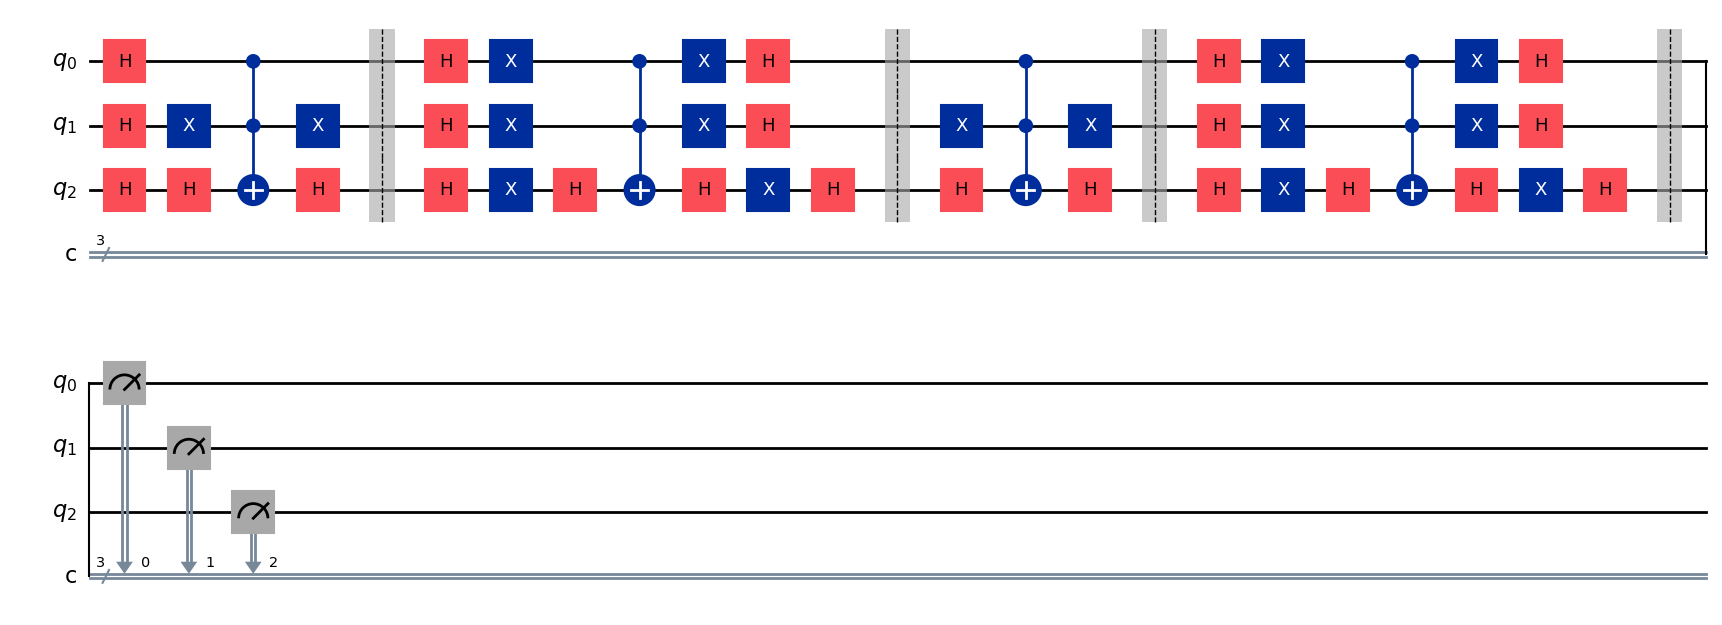

In [108]:
qc.measure(range(n), range(n))
qc.draw('mpl')

#### ***7. Hasil***

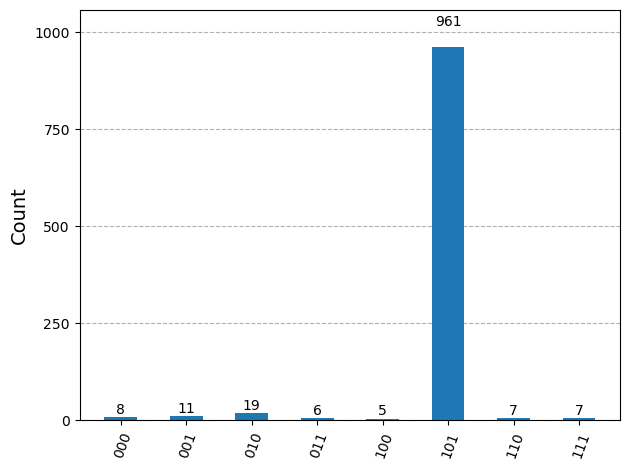

In [109]:
backend = AerSimulator()
qc_transpiled = transpile(qc, backend)
job = backend.run(qc_transpiled, shots=1024)
result = job.result()
counts = result.get_counts(qc)

plot_histogram(counts)

#### ***8. Menghitung Probabilitas Target***

In [110]:
prob_target = counts.get(target, 0) / 1024
print(f"Probabilitas mendapatkan target '{target}': {prob_target*100:.1f}%")

Probabilitas mendapatkan target '101': 93.8%
